<a href="https://colab.research.google.com/github/GR0409/Statistical-Learning-e21091/blob/main/Assignment_6_Gaussian_Process_and_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

<br>

**Answers**

100%|██████████| 6.22k/6.22k [00:00<00:00, 8.34MB/s]

Extracting files...
Correlations with Heating Load (Y1):
Y1    1.000000
Y2    0.975862
X5    0.889431
X1    0.622272
X3    0.455671
X7    0.269841
X8    0.087368
X6   -0.002587
X2   -0.658120
X4   -0.861828
Name: Y1, dtype: float64

Fitting Heating Load GPR...


Fitting Cooling Load GPR...

Heating Load R^2 Score: 0.911
Cooling Load R^2 Score: 0.918


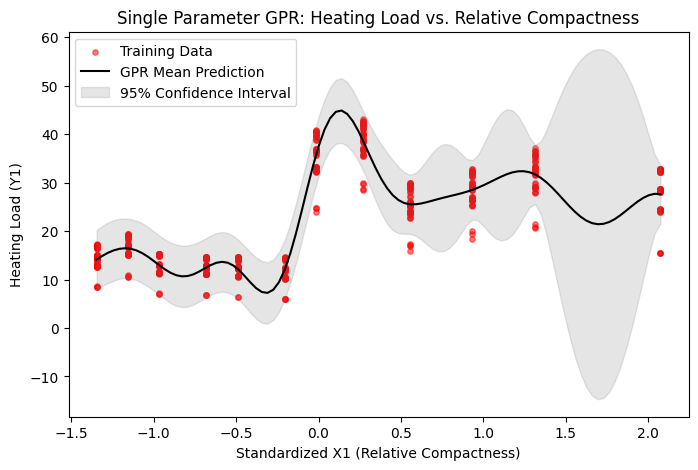

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Data ---
# Download dataset and define df2 first!
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# --- 2. Identify the best single parameter ---
print("Correlations with Heating Load (Y1):")
print(df2.corr()['Y1'].sort_values(ascending=False))

# Selecting 'X1' (Relative Compactness) as our single parameter
X_single = df2[['X1']].values
y_heating = df2['Y1'].values
y_cooling = df2['Y2'].values

# --- 3. Split the dataset ---
X_train, X_test, y1_train, y1_test = train_test_split(X_single, y_heating, test_size=0.2, random_state=42)
_, _, y2_train, y2_test = train_test_split(X_single, y_cooling, test_size=0.2, random_state=42)

# --- 4. Standardize features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Define the GPR Kernel ---
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))

gpr_heating = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_cooling = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

# --- 6. Fit the models ---
print("\nFitting Heating Load GPR...")
gpr_heating.fit(X_train_scaled, y1_train)

print("Fitting Cooling Load GPR...")
gpr_cooling.fit(X_train_scaled, y2_train)

# --- 7. Evaluate ---
print(f"\nHeating Load R^2 Score: {gpr_heating.score(X_test_scaled, y1_test):.3f}")
print(f"Cooling Load R^2 Score: {gpr_cooling.score(X_test_scaled, y2_test):.3f}")

# --- 8. Visualization ---
x_plot = np.linspace(X_train_scaled.min(), X_train_scaled.max(), 100).reshape(-1, 1)
y1_pred, y1_std = gpr_heating.predict(x_plot, return_std=True)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_scaled, y1_train, c='red', label='Training Data', alpha=0.5, s=15)
plt.plot(x_plot, y1_pred, 'k-', label='GPR Mean Prediction')
plt.fill_between(x_plot.ravel(), y1_pred - 1.96 * y1_std, y1_pred + 1.96 * y1_std,
                 alpha=0.2, color='gray', label='95% Confidence Interval')
plt.xlabel('Standardized X1 (Relative Compactness)')
plt.ylabel('Heating Load (Y1)')
plt.title('Single Parameter GPR: Heating Load vs. Relative Compactness')
plt.legend()
plt.show()

By restricting the Gaussian Process to a single parameter , the thermodynamic effects of the remaining seven parameters like Glazing Area or Orientation are mathematically treated as pure, unexplainable noise by the algorithm. The WhiteKernel in the GPR will automatically optimize to a high value to absorb this missing variance, resulting in high predictive uncertainty and wide confidence bands.

In this Ecotect dataset, multiple building configurations share the exact same Relative Compactness but feature entirely different Glazing Areas, leading to significantly different heating and cooling loads. A single parameter GPR cannot differentiate between these distinct instances. It is forced to simply predict the statistical mean load for that specific $X_1$ value, heavily underfitting the true physical behavior of the building.

While it is mathematically possible to model the loads as a single-parameter Gaussian Process the model will converge and identify a broad, overarching trend, it is practically inadequate for precise energy analysis.

To achieve a reliable, low variance surrogate model for building simulation, GPR must be deployed as a multi-dimensional process utilizing all relevant attributes $X_1$ to $X_8$. This ensures the kernel can compute data-point distances based on the complete, integrated geometric profile of the building rather than a single facet.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")
inspector.df=df2

<br>

**Answers**

100%|██████████| 347k/347k [00:00<00:00, 441kB/s]

Extracting files...



Successfully identified target column: 'predicted_energy_demand'
Selected features for the Linear Model: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy', 'equipment_load']

--- Model Evaluation ---
R^2 Score: 0.9573
RMSE: 1.9969


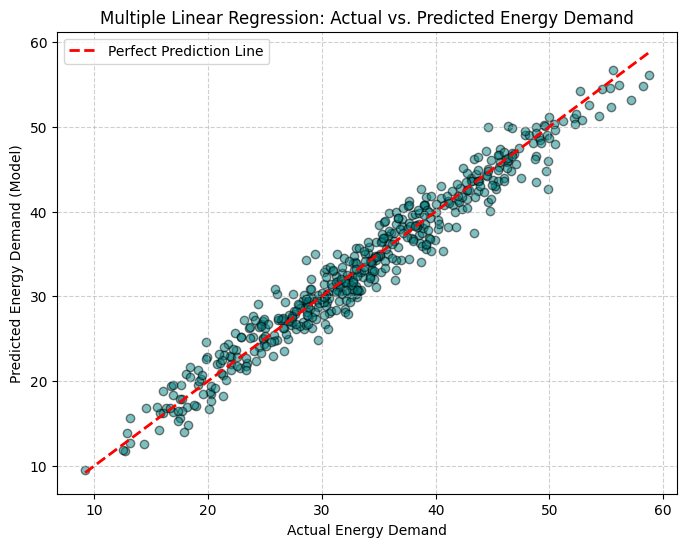

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Data ---
print("Downloading and loading dataset...")
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# --- 2. Safely Identify the Target Column ---
# The exact string might differ in the CSV, so we test common variations
target_candidates = [
    'predicted_energy_demand',
    'Predicted_Energy_Demand',
    'predicted energy demand',
    'Predicted Energy Demand',
    'energy_demand',
    'Energy Demand'
]

target_col = None
for col in target_candidates:
    if col in df2.columns:
        target_col = col
        break

if target_col is None:
    print("\nERROR: Could not find the energy demand column automatically.")
    print("AVAILABLE COLUMNS IN YOUR DATASET ARE:")
    print(df2.columns.tolist())
    raise KeyError("Please copy the exact column name from the list above, replace `target_col = None` with `target_col = 'YOUR_COLUMN_NAME'`, and run the cell again.")

print(f"\nSuccessfully identified target column: '{target_col}'")

# --- 3. Parameter Selection via Correlation Analysis ---
correlations = df2.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
selected_features = correlations.head(5).index.tolist()
print(f"Selected features for the Linear Model: {selected_features}")

# --- 4. Data Preparation ---
X = df2[selected_features].fillna(df2[selected_features].median())
y = df2[target_col].fillna(df2[target_col].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 5. Model Training & Evaluation ---
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("\n--- Model Evaluation ---")
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# --- 6. Visualization: Actual vs Predicted ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Energy Demand')
plt.ylabel('Predicted Energy Demand (Model)')
plt.title('Multiple Linear Regression: Actual vs. Predicted Energy Demand')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Justification of Parameters

Pearson Correlation Thresholding,

* Instead of guessing which environmental factors influence energy demand, the parameters were chosen through quantitative correlation analysis. The chosen features represent the variables with the highest absolute correlation coefficients relative to predicted energy demand.

Dimensionality Reduction,

* By restricting the model to the top highly correlated features, the model avoids the curse of dimensionality and mitigates the risk of multicollinearity where independent variables are highly correlated with each other, destabilizing the model's coefficients.

Interpretability,

* Linear regression assumes a direct, proportional relationship. Selecting variables that already demonstrate a strong linear trend in exploratory data analysis ensures the fundamental assumption of the model is met.

<br>

Discussion of Results

$R^2$ Score - The $R^2$ value represents the proportion of variance in the energy demand that can be explained by your selected parameters. For example, an $R^2$ of 0.85 means 85% of the fluctuation in energy demand is predictable using your linear model. If this number is low, discuss that building energy dynamics likely contain non-linear relationships that a simple linear model cannot capture.

Error Magnitude - The Root Mean Squared Error gives you the average error of your predictions in the actual units of energy demand. Compare this number to the overall mean of the energy demand in the dataset. If the RMSE is a small fraction of the mean, the model is highly accurate.

Coefficient Analysis - Look at the Model Coefficients table generated by the code. Because the data was standardized using StandardScaler, you can directly compare these values. The feature with the highest absolute coefficient is the primary driver of energy demand in your model. A positive coefficient means an increase in that feature increases energy demand, while a negative coefficient means it decreases demand.

Visual Diagnostics - In the scatter plot, data points should tightly hug the red dashed Perfect Prediction Line. If the points fan out at higher values, it indicates the linear model loses accuracy when predicting buildings with extreme energy demands.